We can load the hdf5 file that stores the input_cifs for analysis. (If one uses mp_api to download structures, this step is not necessary. You can directly retrieve structure related information from the API.)

In [71]:
from utils.dataloader import load_data, load_cif_file_from_string
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.core.periodic_table import Element
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mp_api.client import MPRester


In [38]:
with MPRester() as mpr:
    # download all mp data for reference
    all_mp_data = mpr.materials.summary.search(num_sites=(10, 100), fields=["material_id", "structure", "nsites", "elements", "symmetry"])
    mp_ids = [data.material_id for data in all_mp_data]
    structures = [data.structure for data in all_mp_data]
    nsites = [data.nsites for data in all_mp_data]
    elements = [data.elements for data in all_mp_data]
    symmetries = [data.symmetry for data in all_mp_data]

all_mp_df = pd.DataFrame({
    "material_id": mp_ids,
    "structure": structures,
    "nsites": nsites,
    "elements": elements,
    "symmetry": symmetries
})

all_mp_df

Retrieving SummaryDoc documents:   0%|          | 0/111336 [00:00<?, ?it/s]

,material_id,structure,nsites,elements,symmetry
0,mp-32800,"[[ 2.1830569 1.2966013 19.29112704] Ac, [0....",40,"[Ac, S]",crystal_system=<CrystalSystem.tet: 'Tetragonal...
1,mp-977351,"[[-3.80988682 -2.19964136 0.45641987] Ac, [-7...",10,"[Ac, S]",crystal_system=<CrystalSystem.trig: 'Trigonal'...
2,mp-1232311,"[[2.823761 0. 2.0444915] Ac, [0. ...",10,"[Ac, Cu, F, O]",crystal_system=<CrystalSystem.tet: 'Tetragonal...
3,mp-1215094,"[[0. 0. 0.] Ag, [ 0. 0. 28.1906...",10,"[Ag, As, Se]",crystal_system=<CrystalSystem.ortho: 'Orthorho...
4,mp-18125,"[[5.48781898 4.9540164 2.67787168] Ag, [ 0. ...",22,"[Ag, Au, F]",crystal_system=<CrystalSystem.mono: 'Monoclini...
...,...,...,...,...,...
111331,mp-1202959,[[ 0.00000000e+00 -6.71264400e+00 8.47567875e...,36,"[S, Zn]",crystal_system=<CrystalSystem.trig: 'Trigonal'...
111332,mp-1244890,"[[ 6.48888182 14.8451405 12.06765749] Zn, [5....",100,"[S, Zn]",crystal_system=<CrystalSystem.tri: 'Triclinic'...
111333,mp-1244921,"[[5.22844018 4.18811002 1.12693267] Zn, [6.205...",100,"[S, Zn]",crystal_system=<CrystalSystem.tri: 'Triclinic'...
111334,mp-1244922,"[[12.36442153 7.37471118 0.65605428] Zn, [5....",100,"[S, Zn]",crystal_system=<CrystalSystem.tri: 'Triclinic'...


In [39]:
# all the actions have almost the same input_cifs, except some small differences
# for example, if there's only one type of element in the structure, swapping atoms is meaningless,
# and thus those structures will be excluded from input_cifs for swap_atom_action,
# but the difference is very small,
# so it will be enough to just analyze the input_cifs for add_atom_action
input_cifs = load_data("../data/", action_name="add_atom_action") 
input_cifs

# load all the structures
cif_strings = input_cifs["input_cif"].tolist()
structures = [load_cif_file_from_string(cif_str) for cif_str in cif_strings]


D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomW

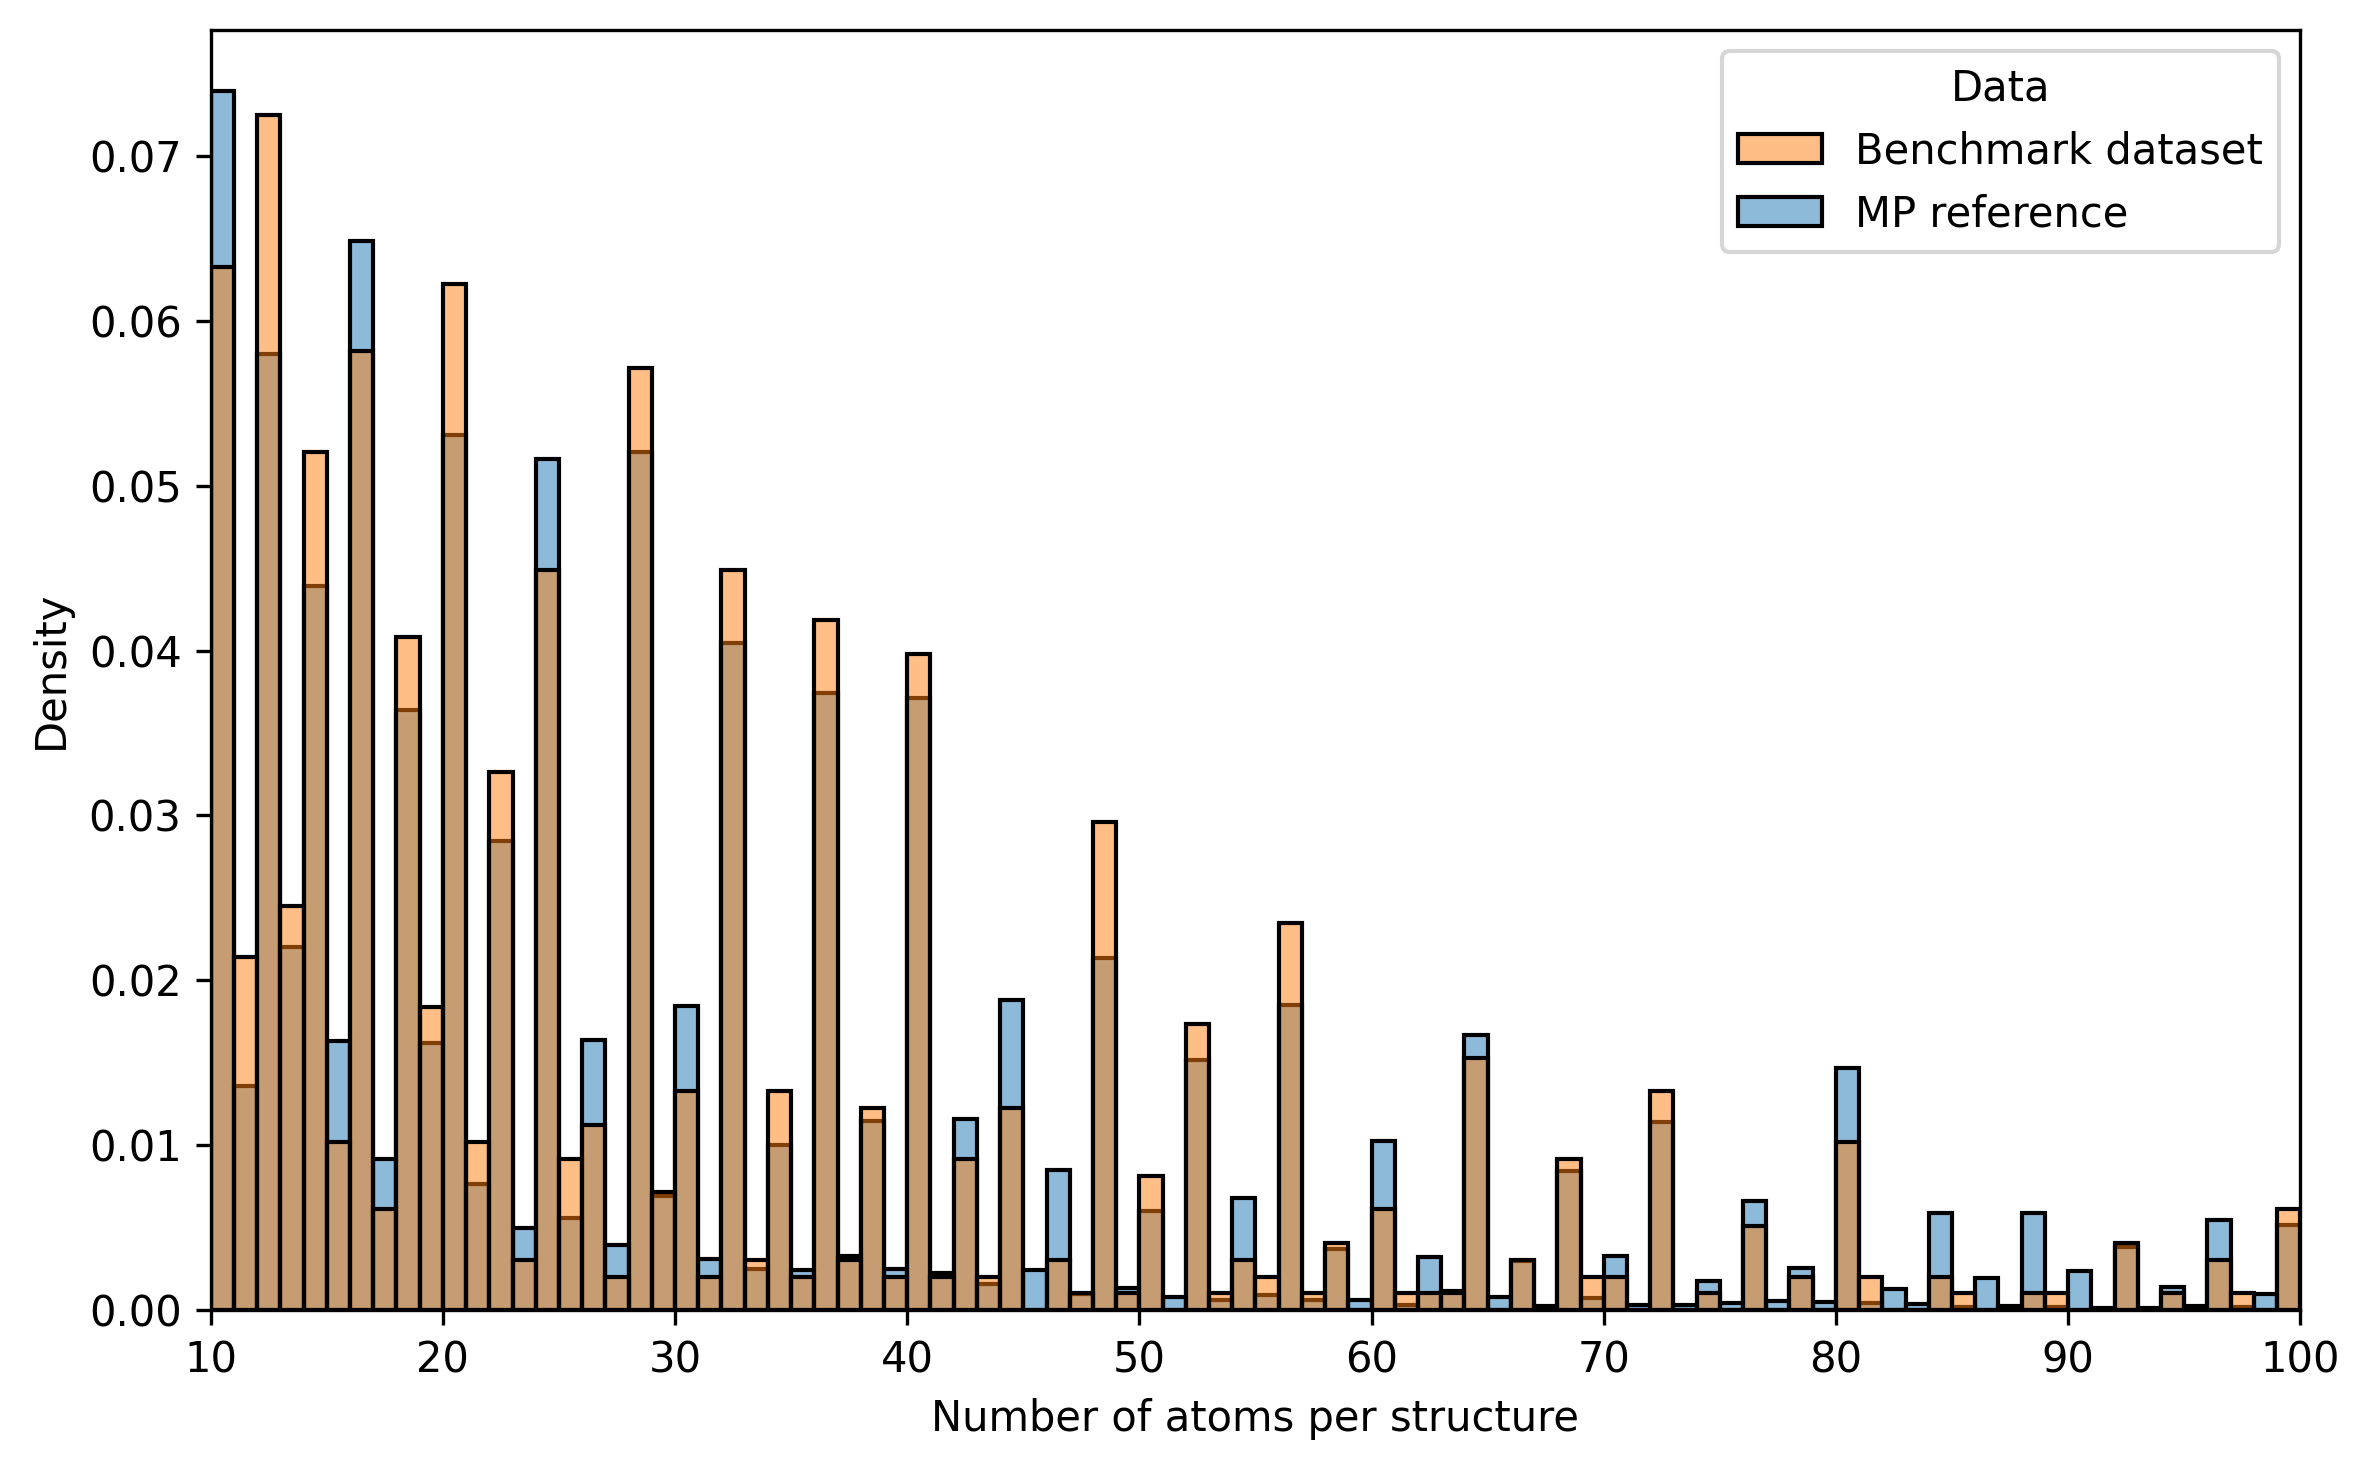

In [44]:
# compare dataset natoms distribution to MP reference using fancy overlays
natoms_mp = all_mp_df["nsites"].to_numpy()
natoms_dataset = np.array([len(structure) for structure in structures])
comparison_df = pd.DataFrame({
    "natoms": np.concatenate([natoms_dataset, natoms_mp]),
    "Data": ["Benchmark dataset"] * len(natoms_dataset) + ["MP reference"] * len(natoms_mp)
})

bins = np.arange(10, 101)
palette = {"Benchmark dataset": "#ff7f0e", "MP reference": "#1f77b4"}

plt.figure(dpi=300, figsize=(8, 5))
sns.histplot(
    data=comparison_df,
    x="natoms",
    hue="Data",
    stat="density",
    bins=bins,
    # element="step",
    fill=True,
    common_norm=False,
    palette=palette,
    linewidth=1,
    legend=True
)
# sns.kdeplot(
#     data=comparison_df,
#     x="natoms",
#     hue="Data",
#     common_norm=False,
#     palette=palette,
#     linewidth=1,
#     alpha=0.5,
#     legend=False
# )

plt.xlabel("Number of atoms per structure")
plt.ylabel("Density")
# plt.title("natoms Distribution: Dataset vs MP Reference")
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, labels, frameon=False)
plt.xlim(10, 100)


plt.tight_layout()
plt.show()

In [45]:
# elements distribution, showing in histogram
element_counts = {}
for structure in structures:
    for site in structure:
        symbol = site.specie.symbol
        element_counts[symbol] = element_counts.get(symbol, 0) + 1

# normalize counts
total = sum(element_counts.values())
if total > 0:
    for element in element_counts:
        element_counts[element] /= total


element_counts_mp = {}
for structure in all_mp_df["structure"]:
    for site in structure:
        symbol = site.specie.symbol
        element_counts_mp[symbol] = element_counts_mp.get(symbol, 0) + 1

# normalize counts
total_mp = sum(element_counts_mp.values())
if total_mp > 0:
    for element in element_counts_mp:
        element_counts_mp[element] /= total_mp

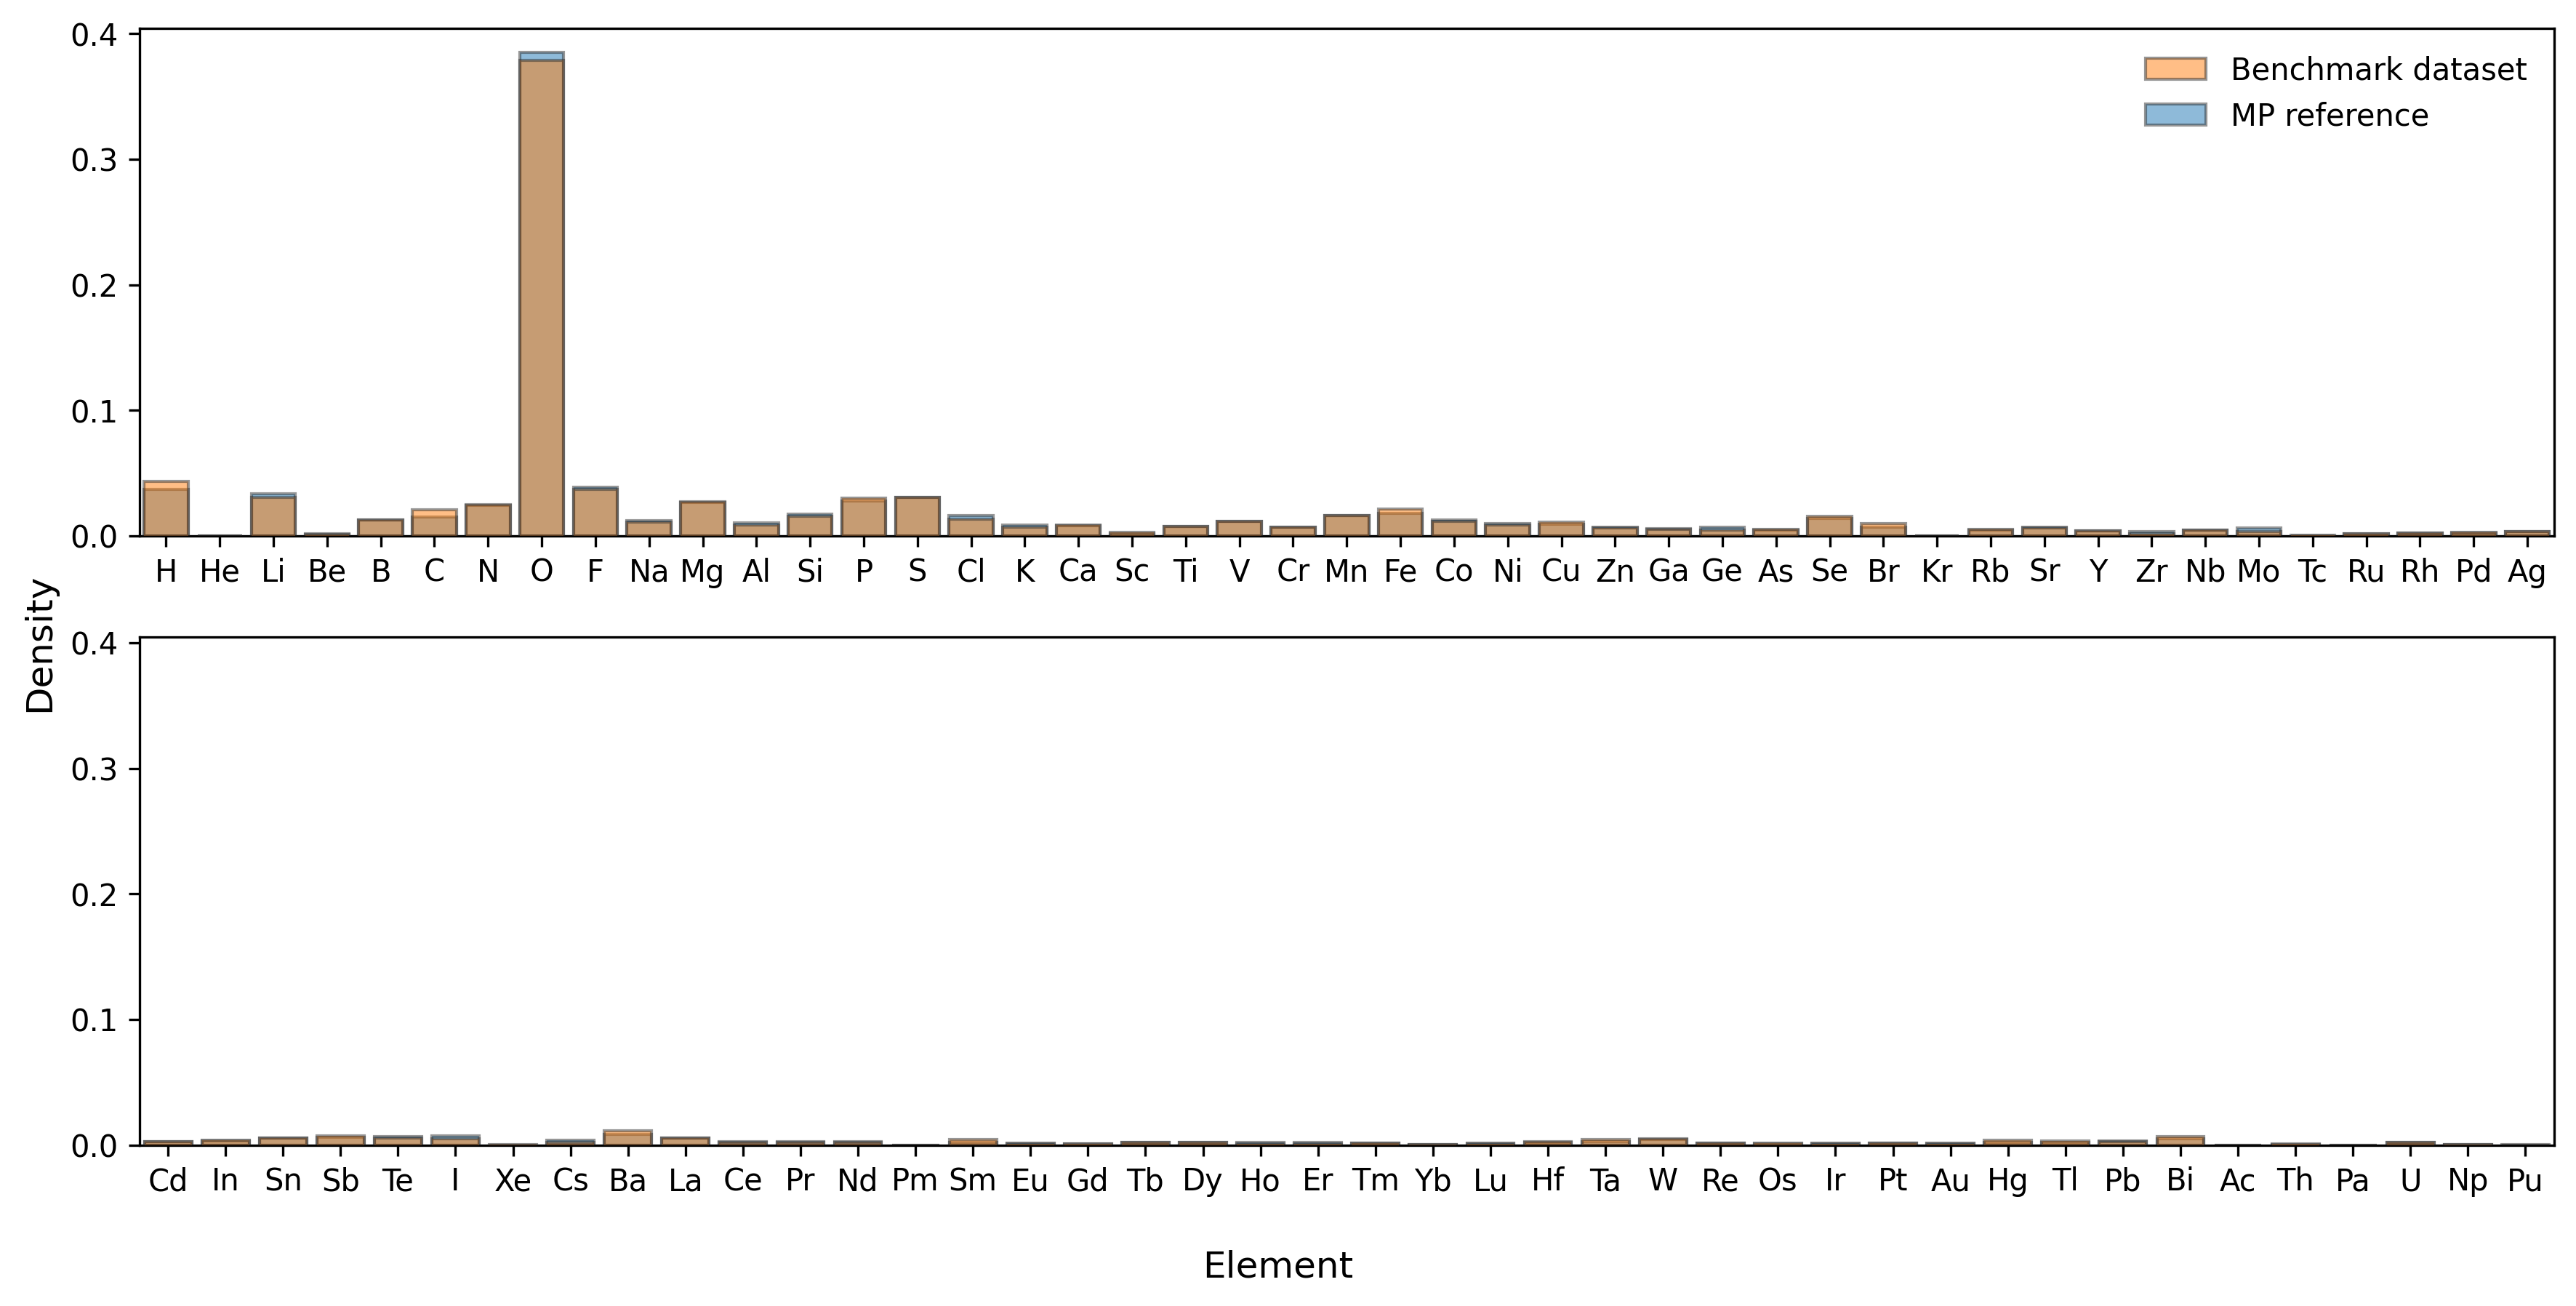

In [107]:
import math

# chunked element distribution comparison inspired by the natoms histogram style
all_elements = sorted(
    set(element_counts) | set(element_counts_mp),
    key=lambda symbol: Element(symbol).Z,
)
if not all_elements:
    raise ValueError("No element frequency data available for plotting.")

chunk_size = 45  # number of elements per row
n_rows = math.ceil(len(all_elements) / chunk_size)
palette = {"Benchmark dataset": "#ff7f0e", "MP reference": "#1f77b4"}
edge_color = "#2f2f2f"

fig, axes = plt.subplots(n_rows, 1, figsize=(12, 3 * n_rows), dpi=300, sharey=True)
if n_rows == 1:
    axes = [axes]

bar_width = 0.82
for row_idx, ax in enumerate(axes):
    start = row_idx * chunk_size
    end = start + chunk_size
    chunk = all_elements[start:end]
    if not chunk:
        ax.axis("off")
        continue

    x = np.arange(len(chunk))
    dataset_vals = np.array([element_counts.get(elem, 0.0) for elem in chunk])
    mp_vals = np.array([element_counts_mp.get(elem, 0.0) for elem in chunk])

    ax.bar(
        x,
        dataset_vals,
        width=bar_width,
        color=palette["Benchmark dataset"],
        alpha=0.5,
        edgecolor=edge_color,
        linewidth=1,
        label="Benchmark dataset",
        zorder=3,
    )
    ax.bar(
        x,
        mp_vals,
        width=bar_width,
        color=palette["MP reference"],
        alpha=0.5,
        edgecolor=edge_color,
        linewidth=1,
        label="MP reference",
        zorder=2,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(chunk)
    ax.set_xlim(-0.5, len(chunk) - 0.5)

    if row_idx == 0:
        ax.legend(frameon=False, loc="upper right")

fig.supxlabel("Element")
fig.supylabel("Density")
fig.tight_layout(h_pad=1.4)
plt.show()

In [67]:
# from pymatviz import ptable_heatmap_splits_plotly

# # combine dataset and reference element frequencies for split plotting
# element_frequency_df = (
#     pd.DataFrame(
#         {
#             "Benchmark Dataset": element_counts,
#             "MP Reference": element_counts_mp,
#         }
#     )
#     .fillna(0)
#     .sort_index()
# )

# ptable_heatmap_splits_plotly(
#     element_frequency_df,
#     colorscale="Blues",
#     colorbar=dict(title="Frequency", orientation="h"),
#     # split_value_fmt="{value:.2%}",
# )


Benchmark dataset: Observed 123 / 230 space groups. Missing 107 total:
  17: P222_1, 22: F222, 23: I222, 24: I2_12_12_1, 27: Pcc2, 28: Pma2, 30: Pnc2, 32: Pba2, 34: Pnn2, 35: Cmm2, 37: Ccc2, 39: Aem2, 49: Pccm, 50: Pban, 51: Pmma
  53: Pmna, 54: Pcca, 56: Pccn, 66: Cccm, 67: Cmme, 68: Ccce, 75: P4, 76: P4_1, 77: P4_2, 78: P4_3, 81: P-4, 83: P4/m, 84: P4_2/m, 89: P422, 90: P42_12
  91: P4_122, 92: P4_12_12, 93: P4_222, 94: P4_22_12, 99: P4mm, 101: P4_2cm, 102: P4_2nm, 103: P4cc, 104: P4nc, 105: P4_2mc, 106: P4_2bc, 107: I4mm, 108: I4cm, 109: I4_1md, 110: I4_1cd
  112: P-42c, 113: P-42_1m, 116: P-4c2, 120: I-4c2, 121: I-42m, 124: P4/mcc, 126: P4/nnc, 128: P4/mnc, 131: P4_2/mmc, 133: P4_2/nbc, 134: P4_2/nnm, 135: P4_2/mbc, 137: P4_2/nmc, 138: P4_2/ncm, 142: I4_1/acd
  144: P3_1, 145: P3_2, 149: P312, 151: P3_112, 153: P3_212, 154: P3_221, 155: R32, 157: P31m, 158: P3c1, 162: P-31m, 163: P-31c, 165: P-3c1, 168: P6, 169: P6_1, 170: P6_5
  171: P6_2, 172: P6_4, 173: P6_3, 174: P-6, 175: P6/m

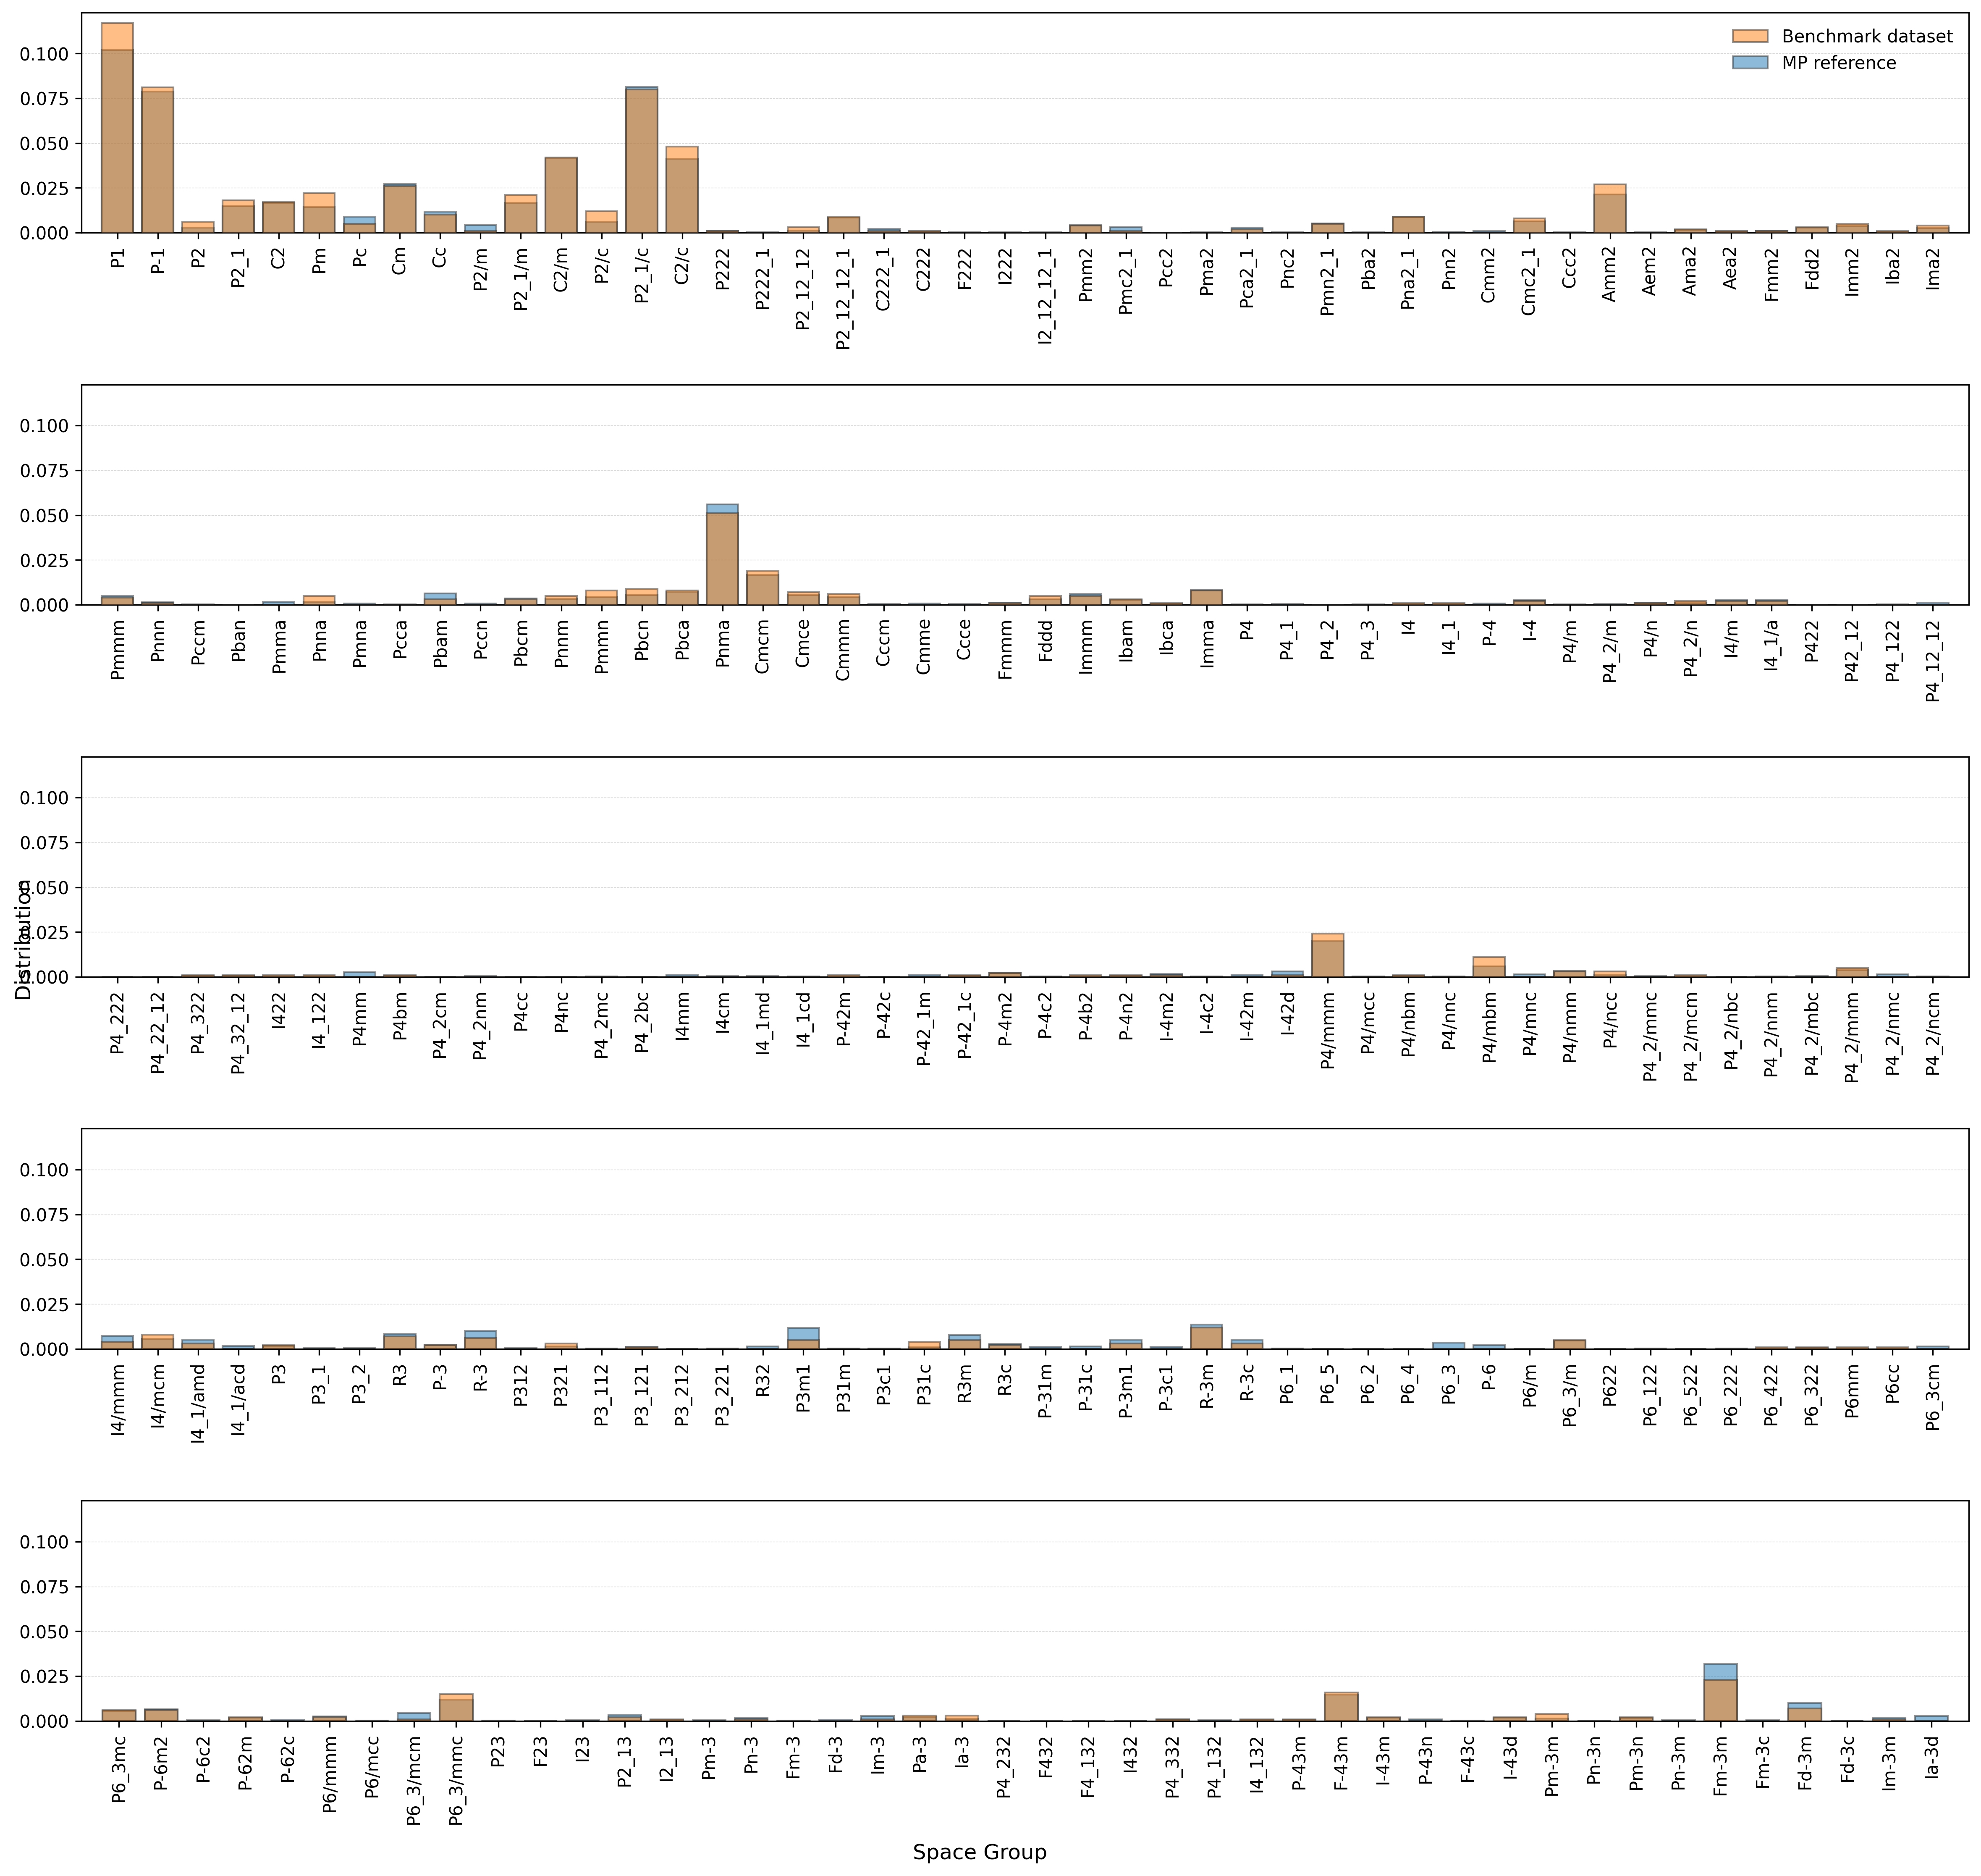

In [114]:
# space group distribution with MP reference overlay
import math
from pymatgen.symmetry.groups import SpaceGroup


def compute_space_group_distribution(structure_iterable):
    counts = {}
    labels = {}
    for structure in structure_iterable:
        sga = SpacegroupAnalyzer(structure)
        spg_number = sga.get_space_group_number()
        spg_symbol = sga.get_space_group_symbol().replace(" ", "")
        counts[spg_number] = counts.get(spg_number, 0) + 1
        labels[spg_number] = spg_symbol
    total = sum(counts.values())
    if total > 0:
        for spg in counts:
            counts[spg] /= total
    return counts, labels


def space_group_distribution_from_symmetry(symmetry_data):
    counts = {}
    labels = {}
    for item in symmetry_data:
        if item is None:
            continue
        spg_number = getattr(item, "number", None)
        spg_symbol = getattr(item, "symbol", None)
        if spg_number is None or spg_symbol is None:
            continue
        spg_symbol = spg_symbol.replace(" ", "")
        counts[spg_number] = counts.get(spg_number, 0) + 1
        labels[spg_number] = spg_symbol
    total = sum(counts.values())
    if total > 0:
        for spg in counts:
            counts[spg] /= total
    return counts, labels


dataset_counts, dataset_labels = compute_space_group_distribution(structures)
mp_counts, mp_labels = space_group_distribution_from_symmetry(all_mp_df["symmetry"].tolist())

space_group_labels = {**mp_labels, **dataset_labels}


def canonical_symbol(sg_number: int) -> str:
    return SpaceGroup.from_int_number(sg_number).symbol.replace(" ", "")


all_space_group_numbers = list(range(1, 231))
for label, counts in [
    ("Benchmark dataset", dataset_counts),
    ("MP reference", mp_counts),
]:
    missing_space_groups = [sg for sg in all_space_group_numbers if sg not in counts]
    present_space_groups = len(counts)
    if missing_space_groups:
        print(
            f"{label}: Observed {present_space_groups} / 230 space groups. "
            f"Missing {len(missing_space_groups)} total:"
        )
        chunk_size = 15
        for start in range(0, len(missing_space_groups), chunk_size):
            chunk = missing_space_groups[start : start + chunk_size]
            formatted = ", ".join(f"{sg}: {canonical_symbol(sg)}" for sg in chunk)
            print("  " + formatted)
    else:
        print(f"{label}: All 230 space groups are present in the dataset.")

space_group_numbers = sorted(set(dataset_counts) | set(mp_counts))
if not space_group_numbers:
    raise ValueError("No space group information available for plotting.")

groups_per_row = 46
n_rows = max(1, math.ceil(len(space_group_numbers) / groups_per_row))
fig, axes = plt.subplots(n_rows, 1, figsize=(16, 3 * n_rows), dpi=300, sharey=True)
if n_rows == 1:
    axes = [axes]

palette = {"Benchmark dataset": "#ff7f0e", "MP reference": "#1f77b4"}
datasets = [
    ("Benchmark dataset", dataset_counts, 0.5, 3),
    ("MP reference", mp_counts, 0.5, 2),
]
edge_color = "#2f2f2f"
bar_width = 0.78

for row_idx, ax in enumerate(axes):
    start = row_idx * groups_per_row
    end = start + groups_per_row
    chunk_numbers = space_group_numbers[start:end]
    if not chunk_numbers:
        ax.axis("off")
        continue

    x = np.arange(len(chunk_numbers))
    xtick_labels = [space_group_labels.get(num, canonical_symbol(num)) for num in chunk_numbers]

    for label, counts, alpha, zorder in datasets:
        values = [counts.get(num, 0.0) for num in chunk_numbers]
        ax.bar(
            x,
            values,
            width=bar_width,
            color=palette[label],
            alpha=alpha,
            edgecolor=edge_color,
            linewidth=1.0,
            label=label if row_idx == 0 else None,
            zorder=zorder,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, rotation=90)
    ax.set_xlim(-0.5 - bar_width / 2, len(chunk_numbers) - 0.5 + bar_width / 2)
    ax.grid(axis="y", linestyle="--", linewidth=0.35, alpha=0.5, zorder=0)

    if row_idx == 0:
        ax.legend(frameon=False, loc="upper right")

fig.supxlabel("Space Group")
fig.supylabel("Distribution")
fig.tight_layout(h_pad=2.0)
plt.show()


In [112]:
all_mp_df['symmetry'][0]

SymmetryData(crystal_system=<CrystalSystem.tet: 'Tetragonal'>, symbol='I-42d', number=122, point_group='-42m', symprec=0.1, angle_tolerance=5.0, version='2.5.0')

Crystal system,Benchmark dataset,MP reference
Triclinic,19.80%,18.07%
Monoclinic,30.80%,28.74%
Orthorhombic,24.00%,22.78%
Tetragonal,8.70%,9.19%
Trigonal,5.50%,7.89%
Hexagonal,4.10%,4.78%
Cubic,7.10%,8.55%


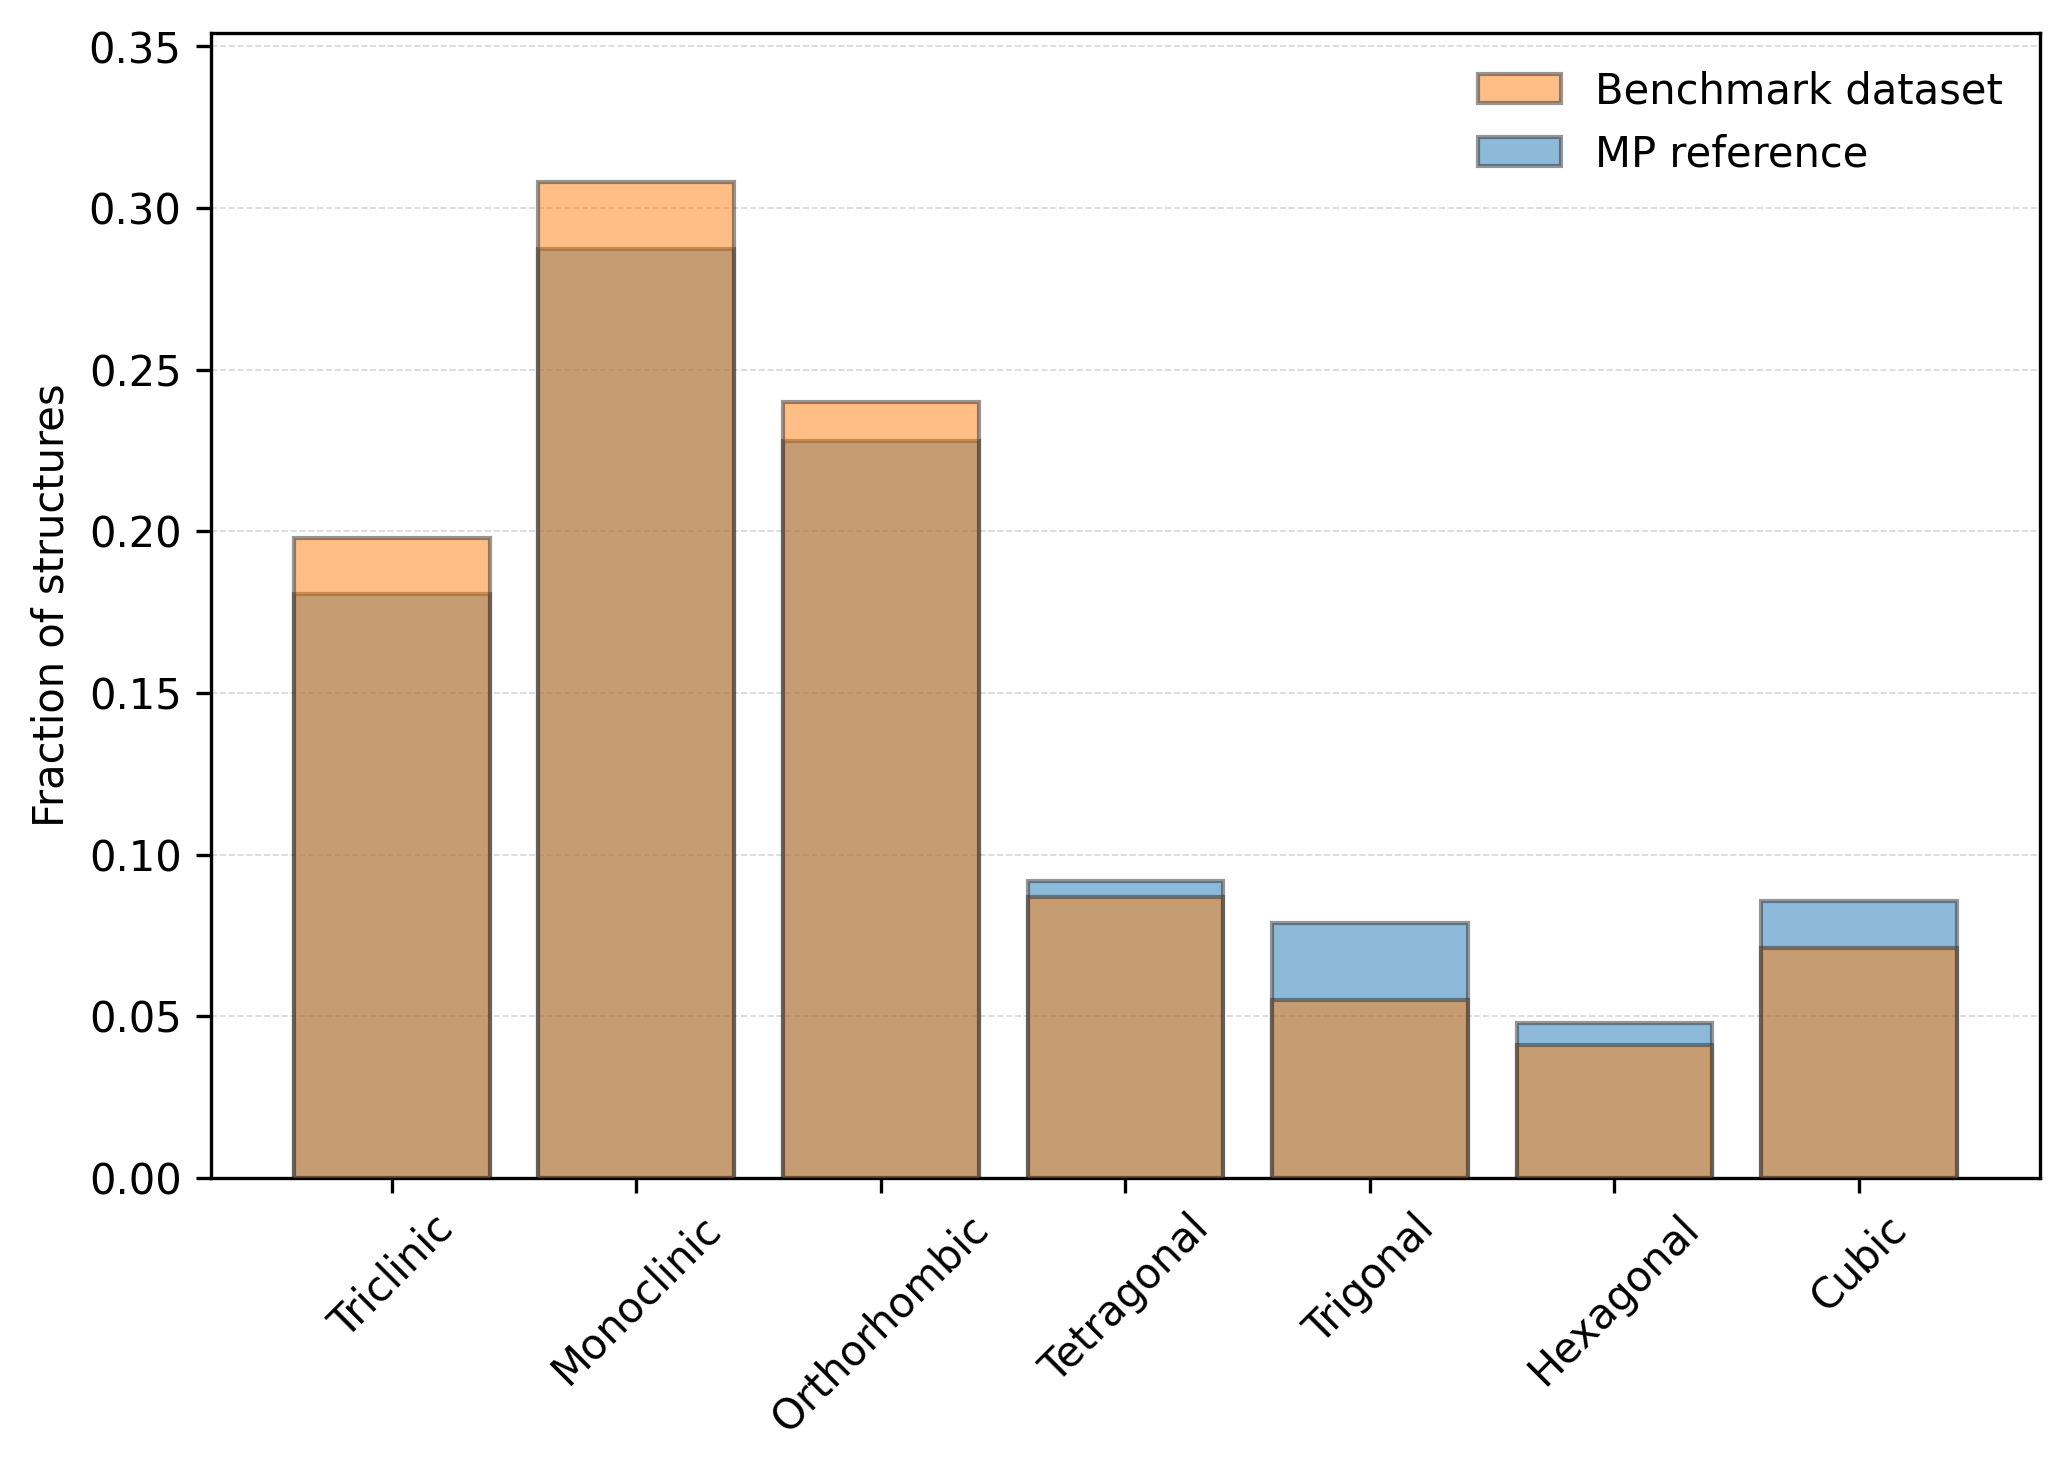

In [119]:
from collections import Counter

crystal_system_order = [
    "Triclinic",
    "Monoclinic",
    "Orthorhombic",
    "Tetragonal",
    "Trigonal",
    "Hexagonal",
    "Cubic",
]

def label_system(system_value):
    text = getattr(system_value, "value", system_value)
    return str(text).capitalize()


def normalized(counter):
    total = sum(counter.values())
    if total == 0:
        return {name: 0.0 for name in crystal_system_order}
    return {name: counter.get(name, 0) / total for name in crystal_system_order}


def crystal_system_distribution(structure_iterable=None, symmetry_iterable=None):
    counts = Counter()
    if structure_iterable is not None:
        for structure in structure_iterable:
            system = SpacegroupAnalyzer(structure).get_crystal_system()
            counts[label_system(system)] += 1
    if symmetry_iterable is not None:
        for symmetry in symmetry_iterable:
            if symmetry is None:
                continue
            system = getattr(symmetry, "crystal_system", None)
            if system is None:
                continue
            counts[label_system(system)] += 1
    return normalized(counts)


dataset_frac = crystal_system_distribution(structure_iterable=structures)
mp_frac = crystal_system_distribution(symmetry_iterable=all_mp_df["symmetry"]) 

rows = [
    {
        "Crystal system": system,
        "Benchmark dataset": dataset_frac[system],
        "MP reference": mp_frac[system],
    }
    for system in crystal_system_order
]
crystal_system_df = pd.DataFrame(rows)

display(
    crystal_system_df.style
    .format({"Benchmark dataset": "{:.2%}", "MP reference": "{:.2%}"})
    .hide(axis="index")
)

x = np.arange(len(crystal_system_order))
bar_width = 0.8
palette = {"Benchmark dataset": "#ff7f0e", "MP reference": "#1f77b4"}
plt.figure(dpi=300, figsize=(7, 5))
plt.bar(
    x,
    [dataset_frac[s] for s in crystal_system_order],
    width=bar_width,
    color=palette["Benchmark dataset"],
    alpha=0.5,
    edgecolor="#2f2f2f",
    linewidth=1,
    label="Benchmark dataset",
    zorder=3,
)
plt.bar(
    x,
    [mp_frac[s] for s in crystal_system_order],
    width=bar_width,
    color=palette["MP reference"],
    alpha=0.5,
    edgecolor="#2f2f2f",
    linewidth=1,
    label="MP reference",
    zorder=2,
)
plt.ylabel("Fraction of structures")
plt.xticks(x, crystal_system_order, rotation=45)
plt.ylim(0, max(max(dataset_frac.values()), max(mp_frac.values())) * 1.15 if crystal_system_order else 1)
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5, zorder=1)
plt.tight_layout()
plt.show()
